# Calibration du Modèle de Heston — SPY Options (Kaggle)

**Calibration par inversion de Fourier** sur données réelles d'options SPY.

Méthodes : Levenberg-Marquardt, Évolution Différentielle, Hybride (DE+LM).

## 0 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import time

from main import (
    HestonParams, HestonPricer, BlackScholes,
    MarketData, CalibrationResult,
    LMCalibrator, DECalibrator, HybridCalibrator,
    MultiDayCalibrator,
    compare_results
)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("Imports OK")

Imports OK


## 1 — Configuration & chargement des données

**6 fichiers disponibles** (2019-2024), ~250 jours chacun, ~7000-9500 contrats/jour.

| Fichier | Période | Contexte marché |
|---|---|---|
| `spy_options_data_19.json` | 2019 | Marché haussier, vol basse |
| `spy_options_data_20.json` | 2020 | COVID crash, vol extrême |
| `spy_options_data_21.json` | 2021 | Recovery, meme stocks |
| `spy_options_data_22.json` | 2022 | Bear market, hausse taux |
| `spy_options_data_23.json` | 2023 | Rally IA, vol modérée |
| `spy_options_data_24.json` | 2024 | Continuation haussière |

**Calibration multi-jours** : on charge N jours **consécutifs** (même régime de marché) et on calibre un jeu unique de paramètres Heston sur l'ensemble. Chaque jour a son propre S0, mais les 5 paramètres (v0, κ, θ, σ, ρ) sont partagés.

Modifier `DAY_START` / `DAY_END` pour contrôler la quantité de données.

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              CONFIGURATION — MODIFIER ICI                   ║
# ╚══════════════════════════════════════════════════════════════╝

# --- Fichiers et jours ---
ALL_FILES = [
    'data/spy_options_data_19.json',   # 2019 (251 jours)
    'data/spy_options_data_20.json',   # 2020 (252 jours)
    'data/spy_options_data_21.json',   # 2021 (252 jours)
    'data/spy_options_data_22.json',   # 2022 (251 jours)
    'data/spy_options_data_23.json',   # 2023 (250 jours)
    'data/spy_options_data_24.json',   # 2024 (252 jours)
]

# Choisir LE fichier et la plage de jours pour la calibration
DATA_FILE = 'data/spy_options_data_24.json'   # un fichier = une année

# Plage de jours consécutifs à charger (dans le fichier, 0-251)
# Les paramètres Heston sont stables sur ~quelques semaines
DAY_START = 115                     # début de la plage (~mi-juin)
DAY_END   = 125                     # fin de la plage (~fin juin)
                                    # → ~10 jours consécutifs, même régime de marché

# --- Filtres ---
MONEYNESS_RANGE = (0.90, 1.10)      # large : (0.85, 1.15) | strict : (0.95, 1.05)
MATURITY_RANGE  = (20, 400)         # large : (14, 550)    | strict : (30, 180)
IV_RANGE        = (0.05, 0.60)      # large : (0.03, 0.80) | strict : (0.08, 0.40)
MIN_VOLUME      = 1                 # large : 1            | strict : 50
MIN_OI          = 10                # large : 10           | strict : 200
MIN_OPT_PER_MAT = 5                # large : 3            | strict : 15

# --- Taux (ajuster selon la période) ---
RISK_FREE_RATE  = 0.053             # Fed funds rate mi-2024
DIVIDEND_YIELD  = 0.013             # SPY dividend yield

n_days = DAY_END - DAY_START
print(f"Configuration :")
print(f"  Fichier     : {DATA_FILE}")
print(f"  Jours       : {n_days} (indices {DAY_START} à {DAY_END-1})")
print(f"  Moneyness   : {MONEYNESS_RANGE}")
print(f"  Maturités   : {MATURITY_RANGE[0]}j - {MATURITY_RANGE[1]}j")
print(f"  IV          : [{IV_RANGE[0]:.0%}, {IV_RANGE[1]:.0%}]")
print(f"  Liquidité   : vol > {MIN_VOLUME}, OI > {MIN_OI}")

Configuration :
  Fichier     : data/spy_options_data_24.json
  Jours       : 10 (indices 115 à 124)
  Moneyness   : (0.9, 1.1)
  Maturités   : 20j - 400j
  IV          : [5%, 60%]
  Liquidité   : vol > 1, OI > 10


In [3]:
# Chargement d'une plage de jours consécutifs
markets = MarketData.from_json_range(
    DATA_FILE,
    day_start=DAY_START,
    day_end=DAY_END,
    r=RISK_FREE_RATE,
    q=DIVIDEND_YIELD,
    min_maturity_days=MATURITY_RANGE[0],
    max_maturity_days=MATURITY_RANGE[1],
    moneyness_range=MONEYNESS_RANGE,
    iv_range=IV_RANGE,
    min_volume=MIN_VOLUME,
    min_oi=MIN_OI,
    min_options_per_maturity=MIN_OPT_PER_MAT,
)

# Le jour le plus riche pour les visualisations mono-jour
market = max(markets, key=lambda m: len(m.strikes))
total_opts = sum(len(m.strikes) for m in markets)
print(f"\nJour le plus riche : S0={market.S0:.2f}, {len(market.strikes)} options")
print(f"Total multi-jours  : {len(markets)} jours, {total_opts} options")

Fichier : spy_options_data_24.json — jours 115 à 124 (10 jours)
────────────────────────────────────────────────────────────
  2024-06-17 : S0=547.00, 4459 calls -> 507 opts, 20 maturités
  2024-06-18 : S0=548.58, 4349 calls -> 471 opts, 20 maturités
  2024-06-20 : S0=546.55, 4339 calls -> 505 opts, 20 maturités
  2024-06-21 : S0=544.86, 4298 calls -> 497 opts, 20 maturités
  2024-06-24 : S0=542.88, 4344 calls -> 484 opts, 19 maturités
  2024-06-25 : S0=544.92, 4551 calls -> 486 opts, 19 maturités
  2024-06-26 : S0=545.09, 4538 calls -> 514 opts, 19 maturités
  2024-06-27 : S0=546.46, 4598 calls -> 532 opts, 19 maturités
  2024-06-28 : S0=545.00, 4523 calls -> 566 opts, 20 maturités
  2024-07-01 : S0=545.41, 4351 calls -> 482 opts, 19 maturités

TOTAL : 10 jours chargés, 5044 options

Jour le plus riche : S0=545.00, 566 options
Total multi-jours  : 10 jours, 5044 options


## 2 — Exploration des données filtrées

In [4]:
# Statistiques par maturité
df = market.df
print(f"S0 = {market.S0:.2f}")
print(f"Total : {len(df)} options, {df['maturity_days'].nunique()} maturités\n")

stats = df.groupby('maturity_days').agg(
    n_options=('strike', 'size'),
    strike_min=('strike', 'min'),
    strike_max=('strike', 'max'),
    iv_mean=('implied_volatility', 'mean'),
    iv_std=('implied_volatility', 'std'),
).round(4)
print(stats.to_string())

S0 = 545.00
Total : 566 options, 20 maturités

               n_options  strike_min  strike_max  iv_mean  iv_std
maturity_days                                                    
21                    66       492.0       570.0   0.1474  0.0548
28                    41       500.0       575.0   0.1218  0.0318
33                    56       491.0       580.0   0.1300  0.0368
35                    39       510.0       580.0   0.1216  0.0242
42                    11       525.0       575.0   0.1114  0.0174
49                    59       492.0       590.0   0.1300  0.0348
63                    47       495.0       595.0   0.1276  0.0262
84                    21       495.0       595.0   0.1350  0.0347
94                    30       500.0       595.0   0.1164  0.0204
112                   18       500.0       595.0   0.1237  0.0224
125                   19       520.0       590.0   0.1258  0.0175
140                   17       515.0       595.0   0.1313  0.0188
154                   14     

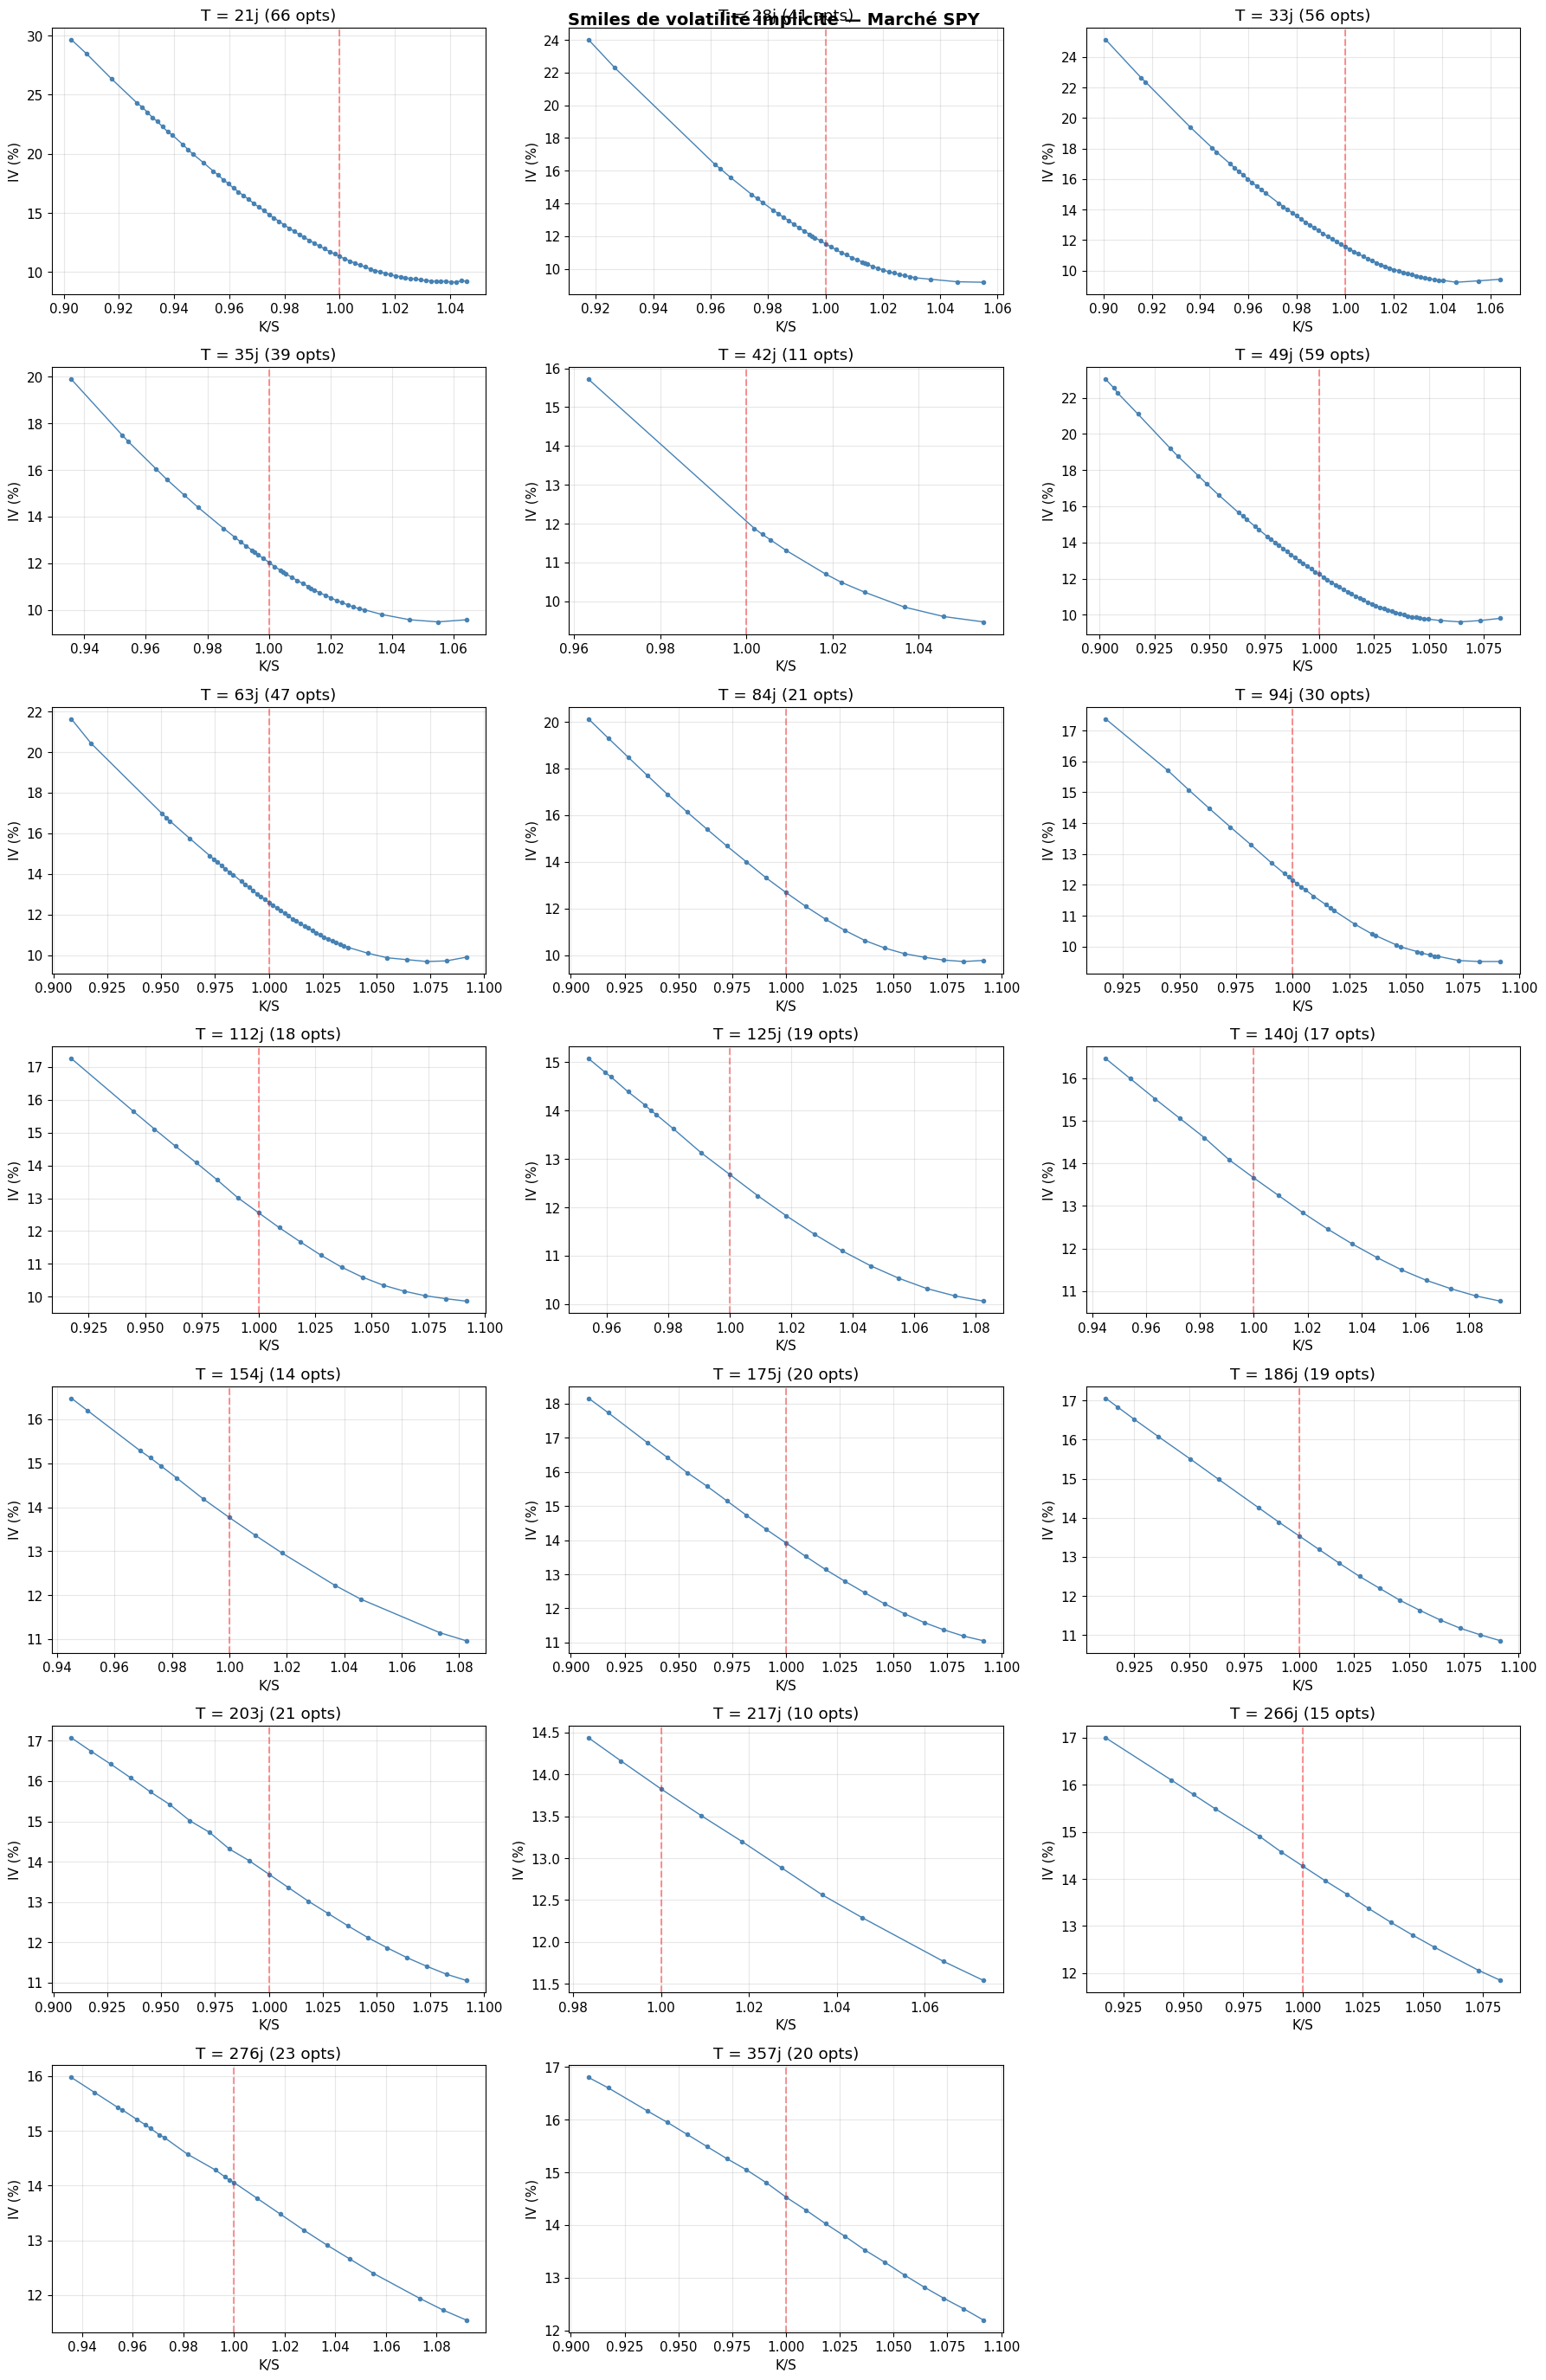

In [5]:
# Smiles de volatilité par maturité
mats = sorted(df['maturity_days'].unique())
n_cols = 3
n_rows = (len(mats) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes)

for idx, Td in enumerate(mats):
    ax = axes[idx // n_cols, idx % n_cols]
    sub = df[df['maturity_days'] == Td].sort_values('moneyness')
    ax.plot(sub['moneyness'], sub['implied_volatility'] * 100, 'o-', color='steelblue', ms=3, lw=1)
    ax.axvline(1.0, color='red', ls='--', alpha=0.4)
    ax.set_xlabel('K/S')
    ax.set_ylabel('IV (%)')
    ax.set_title(f'T = {Td}j ({len(sub)} opts)')

for idx in range(len(mats), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

plt.suptitle("Smiles de volatilité implicite — Marché SPY", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

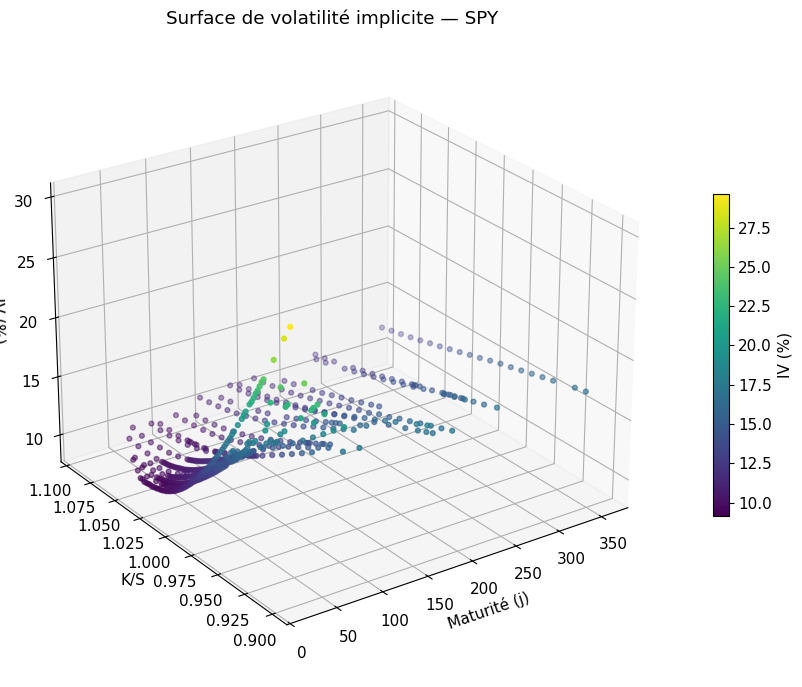

In [6]:
# Surface 3D de volatilité implicite
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    df['maturity_days'], df['moneyness'], df['implied_volatility'] * 100,
    c=df['implied_volatility'] * 100, cmap='viridis', s=12
)
ax.set_xlabel('Maturité (j)')
ax.set_ylabel('K/S')
ax.set_zlabel('IV (%)')
ax.set_title('Surface de volatilité implicite — SPY')
ax.view_init(elev=25, azim=235)
fig.colorbar(sc, shrink=0.5, label='IV (%)')
plt.tight_layout()
plt.show()

## 3 — Validation sur données synthétiques

Avant de calibrer sur les données réelles, on vérifie que les 3 méthodes retrouvent des paramètres connus.

In [7]:
# Données synthétiques avec paramètres connus
true_params = HestonParams(v0=0.04, kappa=1.5, theta=0.05, sigma=0.4, rho=-0.7)

np.random.seed(42)
synth_market = MarketData.generate_synthetic(
    true_params=true_params,
    n_strikes=10,
    n_maturities=5,
    noise=0.003,
)

# Calibration par les 3 méthodes
synth_results = []

for CalibratorClass, kwargs in [
    (LMCalibrator, {}),
    (DECalibrator, {'maxiter': 40, 'popsize': 15}),
    (HybridCalibrator, {'de_maxiter': 20, 'de_popsize': 10}),
]:
    cal = CalibratorClass(synth_market, **kwargs)
    synth_results.append(cal.calibrate())

compare_results(synth_results, true_params=true_params)

[MarketData] Données synthétiques : S0=100.0, 50 points
  Paramètres vrais : HestonParams(
  v0    = 0.040000  (vol0  = 0.2000)
  kappa = 1.500000
  theta = 0.050000  (volLT = 0.2236)
  sigma = 0.400000
  rho   = -0.700000
  Feller: ✗  (2κθ=0.1500 vs σ²=0.1600)
)

▶ Levenberg-Marquardt en cours...

▶ Évolution Différentielle en cours...

▶ Hybride (DE → LM) en cours...
  Phase DE terminée (obj=0.000524), raffinement LM...

  COMPARAISON DES MÉTHODES DE CALIBRATION
Méthode                       Temps (s)    Évals    RMSE IV       v0        κ        θ        σ        ρ
--------------------------------------------------------------------------------------------------------
Levenberg-Marquardt                0.11       57     0.0027   0.0398   1.3532   0.0511   0.4107  -0.6928
Évolution Différentielle           4.65     3225     0.0027   0.0399   1.6357   0.0489   0.4208  -0.6938
Hybride (DE + LM)                  1.76     1237     0.0027   0.0398   1.3531   0.0511   0.4107  -0.6928
------

## 4 — Calibration sur données réelles SPY

**Deux approches :**
1. **Mono-jour** : calibrer sur un seul snapshot (le plus riche en données)
2. **Multi-jours** : calibrer sur tous les jours chargés simultanément — chaque jour a son propre S0/pricer, mais les 5 paramètres Heston sont partagés (supposés stables)

La calibration multi-jours donne des paramètres **plus robustes** car elle exploite plus de données et lisse le bruit d'un seul snapshot.

In [8]:
# ── Calibration mono-jour (meilleur jour) ──
results = []

cal_lm = LMCalibrator(market)
results.append(cal_lm.calibrate())

cal_de = DECalibrator(market, maxiter=40, popsize=15)
results.append(cal_de.calibrate())

cal_hyb = HybridCalibrator(market, de_maxiter=20, de_popsize=10)
results.append(cal_hyb.calibrate())

# ── Calibration multi-jours ──
cal_multi = MultiDayCalibrator(markets, de_maxiter=25, de_popsize=12)
results.append(cal_multi.calibrate())

# Comparaison
compare_results(results)


▶ Levenberg-Marquardt en cours...

▶ Évolution Différentielle en cours...

▶ Hybride (DE → LM) en cours...
  Phase DE terminée (obj=0.044433), raffinement LM...

▶ Calibration multi-jours (10 jours, 5044 options)...


KeyboardInterrupt: 

In [ ]:
# Paramètres détaillés de chaque méthode
for r in results:
    print(r)
    print()

╔══ Levenberg-Marquardt ══
║ Temps      : 1.59 s
║ Évals      : 100
║ RMSE prix  : 0.495852
║ RMSE IV    : 0.0078  (0.78%)
║ HestonParams(
  v0    = 0.014693  (vol0  = 0.1212)
  kappa = 7.228703
  theta = 0.019391  (volLT = 0.1393)
  sigma = 0.582935
  rho   = -0.630187
  Feller: ✗  (2κθ=0.2803 vs σ²=0.3398)
)
╚════════════════════════════════════════

╔══ Évolution Différentielle ══
║ Temps      : 45.32 s
║ Évals      : 3285
║ RMSE prix  : 0.495860
║ RMSE IV    : 0.0078  (0.78%)
║ HestonParams(
  v0    = 0.014689  (vol0  = 0.1212)
  kappa = 7.359169
  theta = 0.019346  (volLT = 0.1391)
  sigma = 0.586721
  rho   = -0.630319
  Feller: ✗  (2κθ=0.2847 vs σ²=0.3442)
)
╚════════════════════════════════════════

╔══ Hybride (DE + LM) ══
║ Temps      : 20.71 s
║ Évals      : 1490
║ RMSE prix  : 0.495852
║ RMSE IV    : 0.0078  (0.78%)
║ HestonParams(
  v0    = 0.014693  (vol0  = 0.1212)
  kappa = 7.228220
  theta = 0.019391  (volLT = 0.1393)
  sigma = 0.582924
  rho   = -0.630184
  Feller: ✗ 

## 5 — Analyse du fit

On prend le **meilleur résultat** (RMSE IV min) et on compare les smiles Heston vs marché.

In [ ]:
# Meilleur résultat
best = min(results, key=lambda r: r.rmse_iv)
params_cal = best.params
print(f"Meilleure méthode : {best.method}")
print(params_cal)

# Calculer les IV Heston sur toutes les options
pricer = HestonPricer(market.S0, market.r, market.q)

t0 = time.time()
iv_heston = np.array([
    pricer.implied_vol(K, T, params_cal)
    for K, T in zip(market.strikes, market.maturities)
])
print(f"\nCalcul des IV Heston : {time.time() - t0:.1f}s pour {len(market.strikes)} options")

# Ajouter au DataFrame
df['iv_heston'] = iv_heston
df['iv_error'] = (iv_heston - df['implied_volatility'].values) * 100  # en %

Meilleure méthode : Évolution Différentielle
HestonParams(
  v0    = 0.014689  (vol0  = 0.1212)
  kappa = 7.359169
  theta = 0.019346  (volLT = 0.1391)
  sigma = 0.586721
  rho   = -0.630319
  Feller: ✗  (2κθ=0.2847 vs σ²=0.3442)
)

Calcul des IV Heston : 0.3s pour 653 options


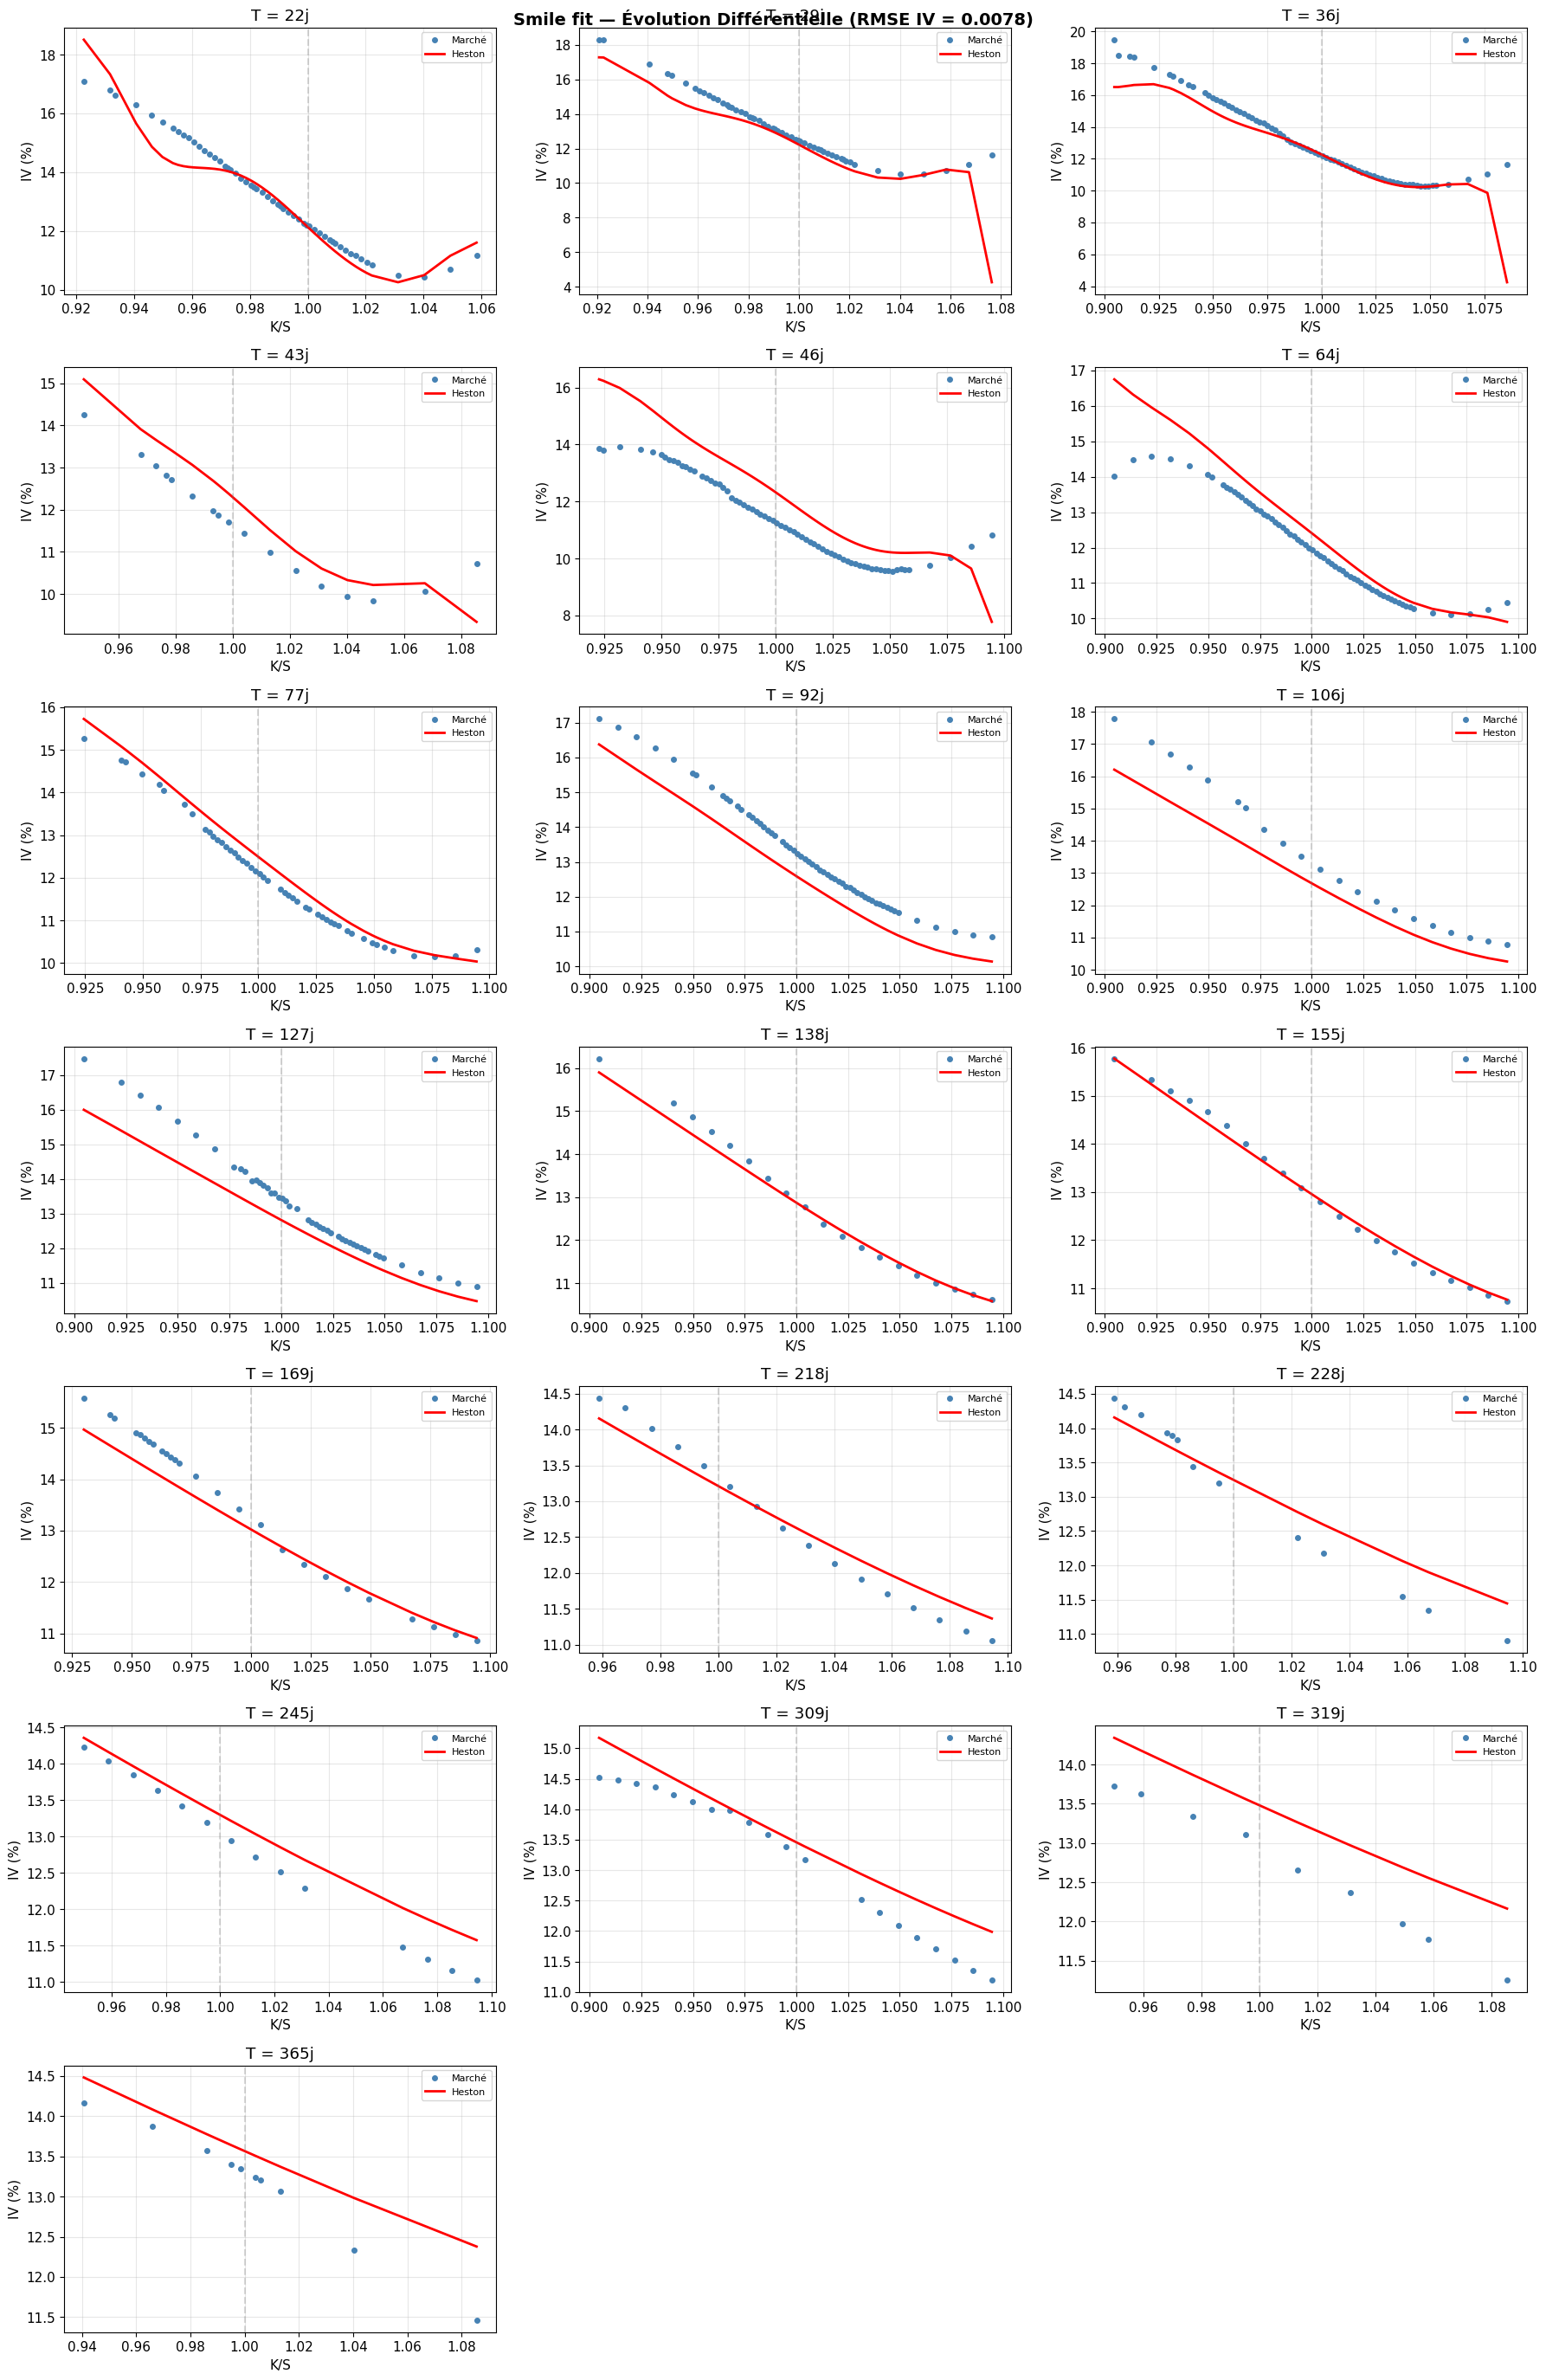

In [ ]:
# Smiles : Marché vs Heston calibré
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes)

for idx, Td in enumerate(mats):
    ax = axes[idx // n_cols, idx % n_cols]
    sub = df[df['maturity_days'] == Td].sort_values('moneyness')
    ax.plot(sub['moneyness'], sub['implied_volatility'] * 100, 'o', color='steelblue', ms=4, label='Marché')
    ax.plot(sub['moneyness'], sub['iv_heston'] * 100, '-', color='red', lw=2, label='Heston')
    ax.axvline(1.0, color='grey', ls='--', alpha=0.3)
    ax.set_xlabel('K/S')
    ax.set_ylabel('IV (%)')
    ax.set_title(f'T = {Td}j')
    ax.legend(fontsize=8)

for idx in range(len(mats), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

plt.suptitle(f"Smile fit — {best.method} (RMSE IV = {best.rmse_iv:.4f})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

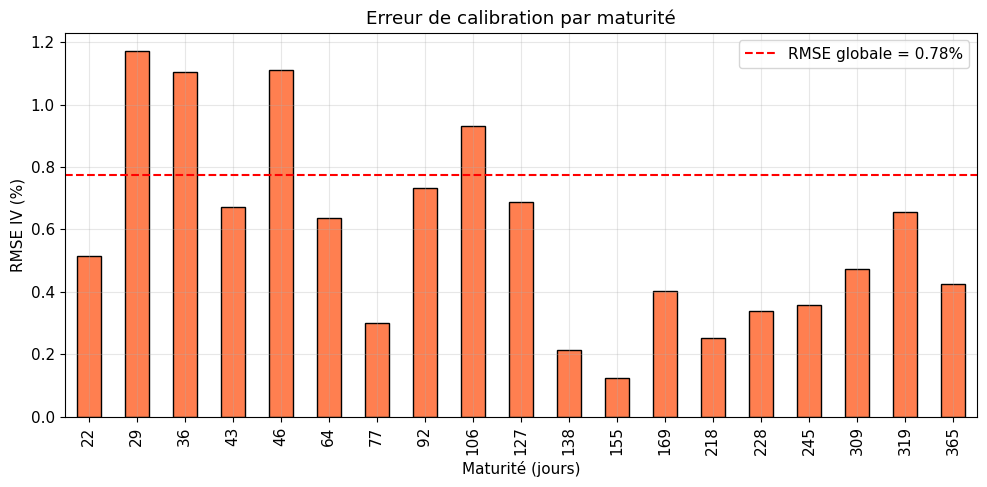

In [ ]:
# RMSE par maturité
rmse_by_mat = df.groupby('maturity_days').apply(
    lambda g: np.sqrt(np.mean((g['iv_heston'] - g['implied_volatility'])**2)) * 100
)

fig, ax = plt.subplots(figsize=(10, 5))
rmse_by_mat.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Maturité (jours)')
ax.set_ylabel('RMSE IV (%)')
ax.set_title('Erreur de calibration par maturité')
ax.axhline(best.rmse_iv * 100, color='red', ls='--', label=f'RMSE globale = {best.rmse_iv*100:.2f}%')
ax.legend()
plt.tight_layout()
plt.show()

## 6 — Comparaison Black-Scholes vs Heston

In [ ]:
# BS flat : sigma = IV ATM moyenne
atm_mask = (df['moneyness'] > 0.98) & (df['moneyness'] < 1.02)
sigma_bs = df.loc[atm_mask, 'implied_volatility'].mean()
print(f"sigma_BS (ATM) = {sigma_bs*100:.2f}%")

# Erreurs (en %)
err_bs = (sigma_bs - df['implied_volatility'].values) * 100
err_heston = (df['iv_heston'].values - df['implied_volatility'].values) * 100

rmse_bs = np.sqrt(np.mean(err_bs**2))
rmse_h = np.sqrt(np.mean(err_heston**2))
print(f"\nRMSE IV :  BS = {rmse_bs:.3f}%  |  Heston = {rmse_h:.3f}%")
print(f"Ratio : Heston {rmse_bs/rmse_h:.1f}x meilleur que BS")

sigma_BS (ATM) = 12.51%

RMSE IV :  BS = 1.822%  |  Heston = 0.775%
Ratio : Heston 2.4x meilleur que BS


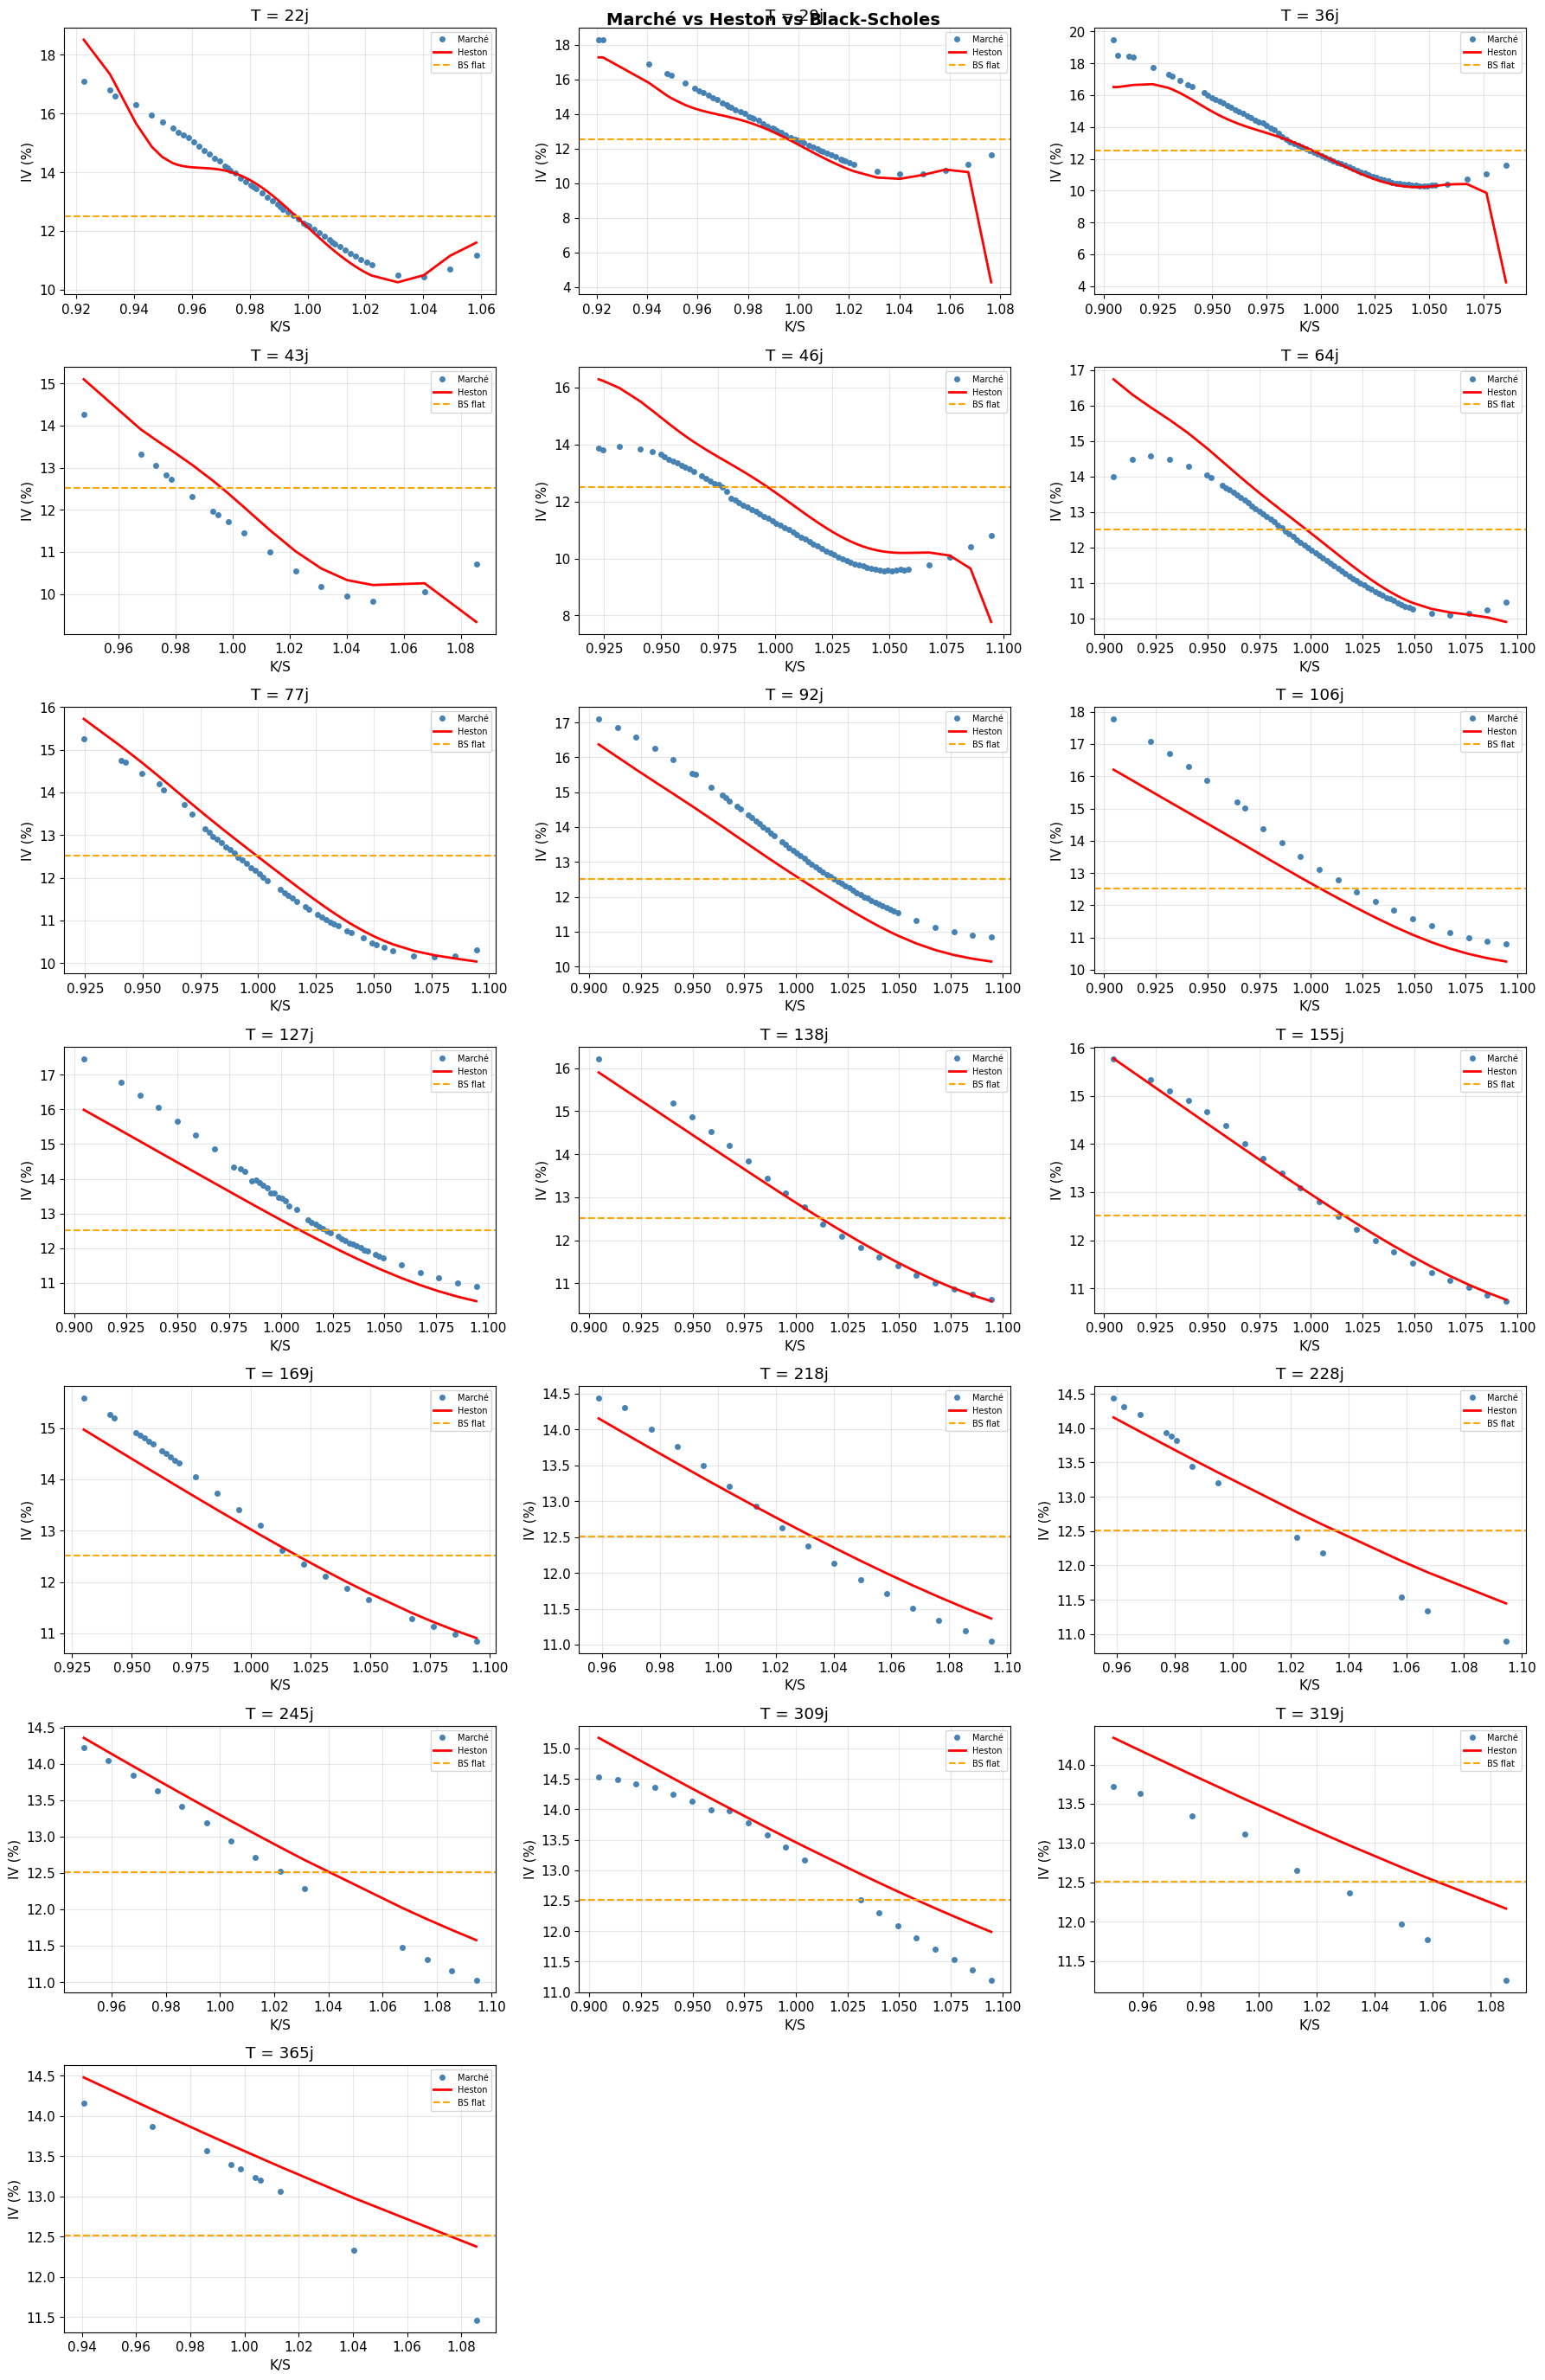

In [ ]:
# BS vs Heston vs Marché — smiles superposés
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes)

for idx, Td in enumerate(mats):
    ax = axes[idx // n_cols, idx % n_cols]
    sub = df[df['maturity_days'] == Td].sort_values('moneyness')
    ax.plot(sub['moneyness'], sub['implied_volatility'] * 100, 'o', color='steelblue', ms=4, label='Marché')
    ax.plot(sub['moneyness'], sub['iv_heston'] * 100, '-', color='red', lw=2, label='Heston')
    ax.axhline(sigma_bs * 100, color='orange', ls='--', lw=1.5, label='BS flat')
    ax.set_xlabel('K/S')
    ax.set_ylabel('IV (%)')
    ax.set_title(f'T = {Td}j')
    ax.legend(fontsize=7)

for idx in range(len(mats), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

plt.suptitle("Marché vs Heston vs Black-Scholes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

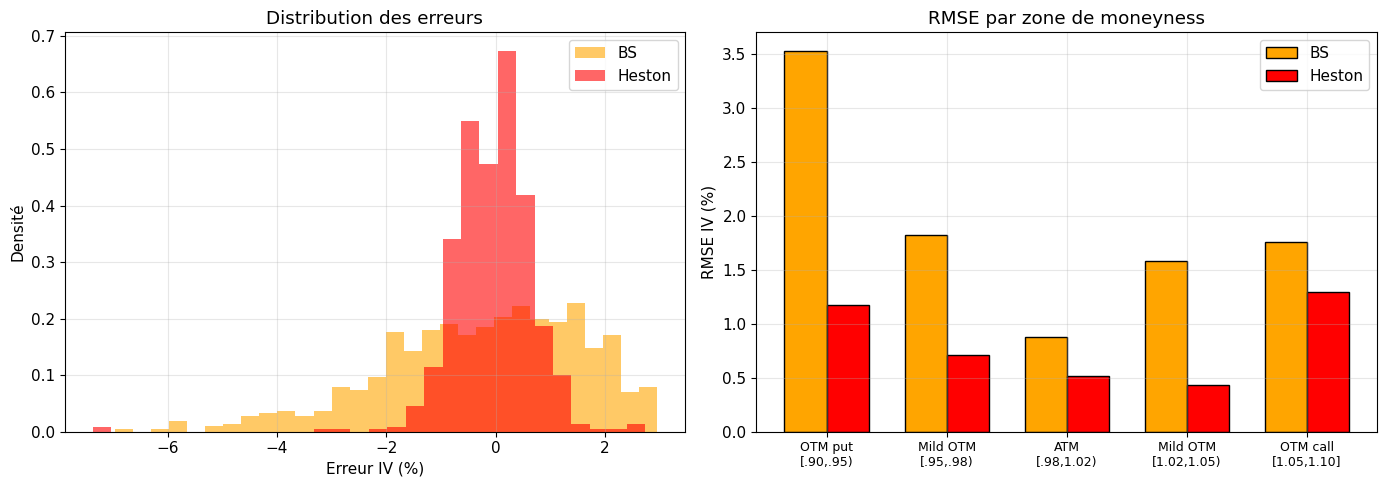

In [ ]:
# Distribution des erreurs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(err_bs, bins=30, alpha=0.6, color='orange', label='BS', density=True)
ax1.hist(err_heston, bins=30, alpha=0.6, color='red', label='Heston', density=True)
ax1.set_xlabel('Erreur IV (%)')
ax1.set_ylabel('Densité')
ax1.set_title('Distribution des erreurs')
ax1.legend()

# Erreur par zone de moneyness
bins_m = [0.90, 0.95, 0.98, 1.02, 1.05, 1.10]
labels_m = ['OTM put\n[.90,.95)', 'Mild OTM\n[.95,.98)', 'ATM\n[.98,1.02)', 'Mild OTM\n[1.02,1.05)', 'OTM call\n[1.05,1.10]']
df['m_bin'] = pd.cut(df['moneyness'], bins=bins_m, labels=labels_m, include_lowest=True)

rmse_zone_bs = df.groupby('m_bin', observed=True).apply(
    lambda g: np.sqrt(np.mean((sigma_bs - g['implied_volatility'])**2)) * 100
)
rmse_zone_h = df.groupby('m_bin', observed=True).apply(
    lambda g: np.sqrt(np.mean((g['iv_heston'] - g['implied_volatility'])**2)) * 100
)

x = np.arange(len(rmse_zone_bs))
w = 0.35
ax2.bar(x - w/2, rmse_zone_bs.values, w, color='orange', label='BS', edgecolor='black')
ax2.bar(x + w/2, rmse_zone_h.values, w, color='red', label='Heston', edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels(rmse_zone_bs.index, fontsize=9)
ax2.set_ylabel('RMSE IV (%)')
ax2.set_title('RMSE par zone de moneyness')
ax2.legend()

plt.tight_layout()
plt.show()

## 7 — Calibration sur tous les jours chargés

On calibre Heston (méthode hybride) sur **chaque jour** indépendamment pour observer l'évolution des paramètres dans le temps.

In [ ]:
# Calibration jour par jour (hybride, le plus fiable)
all_cal_results = []

for i, mkt in enumerate(markets):
    date_str = mkt.df['date'].iloc[0].strftime('%Y-%m-%d')
    print(f"\n[{i+1}/{len(markets)}] {date_str} — {len(mkt.strikes)} options, S0={mkt.S0:.2f}")

    cal = HybridCalibrator(mkt, de_maxiter=15, de_popsize=8)
    res = cal.calibrate()
    res.date = date_str  # on stocke la date
    res.S0 = mkt.S0
    all_cal_results.append(res)

    print(f"  → RMSE IV = {res.rmse_iv:.4f}, v0={res.params.v0:.4f}, "
          f"κ={res.params.kappa:.2f}, θ={res.params.theta:.4f}, "
          f"σ={res.params.sigma:.3f}, ρ={res.params.rho:.3f}")


[1/502] 2023-01-03 — 324 options, S0=380.61

▶ Hybride (DE → LM) en cours...
  Phase DE terminée (obj=0.004363), raffinement LM...
  → RMSE IV = 0.0037, v0=0.0460, κ=2.43, θ=0.0614, σ=0.492, ρ=-0.771

[2/502] 2023-01-04 — 362 options, S0=383.86

▶ Hybride (DE → LM) en cours...
  Phase DE terminée (obj=0.005620), raffinement LM...
  → RMSE IV = 0.0037, v0=0.0454, κ=2.78, θ=0.0620, σ=0.642, ρ=-0.690

[3/502] 2023-01-05 — 330 options, S0=379.51

▶ Hybride (DE → LM) en cours...
  Phase DE terminée (obj=0.002906), raffinement LM...
  → RMSE IV = 0.0029, v0=0.0468, κ=1.90, θ=0.0668, σ=0.600, ρ=-0.684

[4/502] 2023-01-06 — 436 options, S0=388.01

▶ Hybride (DE → LM) en cours...
  Phase DE terminée (obj=0.012590), raffinement LM...
  → RMSE IV = 0.0045, v0=0.0388, κ=1.30, θ=0.0747, σ=0.499, ρ=-0.680

[5/502] 2023-01-09 — 365 options, S0=387.69

▶ Hybride (DE → LM) en cours...
  Phase DE terminée (obj=0.002649), raffinement LM...
  → RMSE IV = 0.0027, v0=0.0450, κ=1.86, θ=0.0601, σ=0.621, ρ=-0

KeyboardInterrupt: 

In [ ]:
# Évolution temporelle des paramètres calibrés
dates_cal = pd.to_datetime([r.date for r in all_cal_results])
v0_arr    = [r.params.v0 for r in all_cal_results]
kappa_arr = [r.params.kappa for r in all_cal_results]
theta_arr = [r.params.theta for r in all_cal_results]
sigma_arr = [r.params.sigma for r in all_cal_results]
rho_arr   = [r.params.rho for r in all_cal_results]
rmse_arr  = [r.rmse_iv * 100 for r in all_cal_results]
s0_arr    = [r.S0 for r in all_cal_results]

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

axes[0, 0].plot(dates_cal, np.sqrt(v0_arr) * 100, 'o-', ms=4, color='tab:blue')
axes[0, 0].set_ylabel('vol initiale (%)')
axes[0, 0].set_title('√v0 — Volatilité instantanée')

axes[0, 1].plot(dates_cal, kappa_arr, 'o-', ms=4, color='tab:orange')
axes[0, 1].set_ylabel('κ')
axes[0, 1].set_title('κ — Vitesse de retour à la moyenne')

axes[1, 0].plot(dates_cal, np.sqrt(theta_arr) * 100, 'o-', ms=4, color='tab:green')
axes[1, 0].set_ylabel('vol long terme (%)')
axes[1, 0].set_title('√θ — Volatilité long terme')

axes[1, 1].plot(dates_cal, sigma_arr, 'o-', ms=4, color='tab:red')
axes[1, 1].set_ylabel('σ (vol of vol)')
axes[1, 1].set_title('σ — Vol of vol')

axes[2, 0].plot(dates_cal, rho_arr, 'o-', ms=4, color='tab:purple')
axes[2, 0].set_ylabel('ρ')
axes[2, 0].set_title('ρ — Corrélation spot/variance')

axes[2, 1].plot(dates_cal, rmse_arr, 'o-', ms=4, color='tab:brown')
axes[2, 1].set_ylabel('RMSE IV (%)')
axes[2, 1].set_title('Qualité du fit')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f"Paramètres Heston calibrés — {len(all_cal_results)} jours", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()